We will start by rewriting the whole ML cycle for the same dataset, using the exact same model and concept as '03-Makemore_MLP'

In [25]:
import torch, torch.nn.functional as F, matplotlib.pyplot as plt
import random

#Loading data and setting up data split

words = open('names.txt', 'r').read().splitlines()

chars = sorted(list(set(''.join(words))))
stoi = {s: i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}

print(f"Characters: \n",chars)
print(f"integer to string: \n",itos)
print(f"String to integer: \n",stoi)

random.seed(42)
random.shuffle(words)

n1=int(len(words)*0.8)
n2=int(len(words)*0.9)

train_words = words[:n1]
val_words = words[n1:n2]
test_words=words[n2:]

def build_dataset(words):

    block_size = 3
    X, Y = [], []

    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]

    X=torch.tensor(X)
    Y=torch.tensor(Y)

    return X,Y

Xtr,Ytr = build_dataset(train_words)
Xval,Yval = build_dataset(val_words)
Xtest,Ytest = build_dataset(test_words)


print(f"\nX training Shape:",Xtr.shape)
print(f" \nX Validation Shape:", Xval.shape)
print(f" \nX Test Shape:", Xtest.shape)


#Building MLP and setting up the training loop
torch.manual_seed(2147483647)
num_iterations = 15000
learning_rate = 0.01
n_hidden1 = 300
n_hidden2 = 27
n_embedding = 10
block_size = 3


C=torch.randn((27,n_embedding), requires_grad=True)
emb = C[Xtr]
x = emb.view(-1, n_embedding * block_size)


W1=torch.randn(n_embedding * block_size, n_hidden1, requires_grad=True)
b1=torch.randn(n_hidden1, requires_grad=True)


W2 = torch.randn(n_hidden1, n_hidden2) * 0.01
W2.requires_grad = True
b2 = torch.zeros(n_hidden2, requires_grad=True)

for k in range(num_iterations):
    #Mini-batch
    ix = torch.randint(0, Xtr.shape[0], (32,))
    #Forward Pass
    emb = C[Xtr[ix]]
    x = emb.view(-1, n_embedding * block_size)
    h_b = torch.tanh(x @ W1 + b1)
    logits = h_b @ W2 + b2

    #Loss
    mean_neg_log = F.cross_entropy(logits, Ytr[ix])

    #Backward Pass
    mean_neg_log.backward()

    #Update

    learning_rate = 0.1 if k < 0.75 * num_iterations else 0.01
    C.data += learning_rate * -C.grad
    W1.data += learning_rate * -W1.grad
    W2.data += learning_rate * -W2.grad
    b1.data += learning_rate * -b1.grad
    b2.data += learning_rate * -b2.grad
    C.grad.zero_()
    W1.grad.zero_()
    W2.grad.zero_()
    b1.grad.zero_()
    b2.grad.zero_()

    #Logging
    print((k, mean_neg_log.item()))

#Evaluating trained model on validation data - compare with final training loss

#Forward Pass on validation data
emb = C[Xval]
x = emb.view(-1,n_embedding * block_size)
h=torch.tanh(x @ W1 + b1)
logits = h @ W2 + b2


#Loss
mean_neg_log = F.cross_entropy(logits, Yval)

print(f"\nValidation Loss:",mean_neg_log.item())


#Forward Pass on training data - final training loss
emb = C[Xtr]
x = emb.view(-1,n_embedding * block_size)
h=torch.tanh(x @ W1 + b1)
logits = h @ W2 + b2


#Loss
mean_neg_log = F.cross_entropy(logits, Ytr)

print(f"\nFinal Training Loss:",mean_neg_log.item())




Characters: 
 ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
integer to string: 
 {1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
String to integer: 
 {'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}

X training Shape: torch.Size([182625, 3])
 
X Validation Shape: torch.Size([22655, 3])
 
X Test Shape: torch.Size([22866, 3])
(0, 3.3115203380584717)
(1, 3.1572535037994385)
(2, 3.1755430698394775)
(3, 3.0994906425476074)
(4, 3.0877959728240967)
(5, 3.040327787399292)
(6, 2.8415796756744385)
(7, 3.14009952545166)
(8, 2.7845394611358643)
(9, 2

One issue that was quietly lurking is the 'saturated tanh' issue, lets break this down step-by-step. When we conduct a backward pass, we start at the loss and propogate backwards through all of the neurons. Particularly, we will go through the tanh activation function which is present at every neuron ('h=torch.tanh(x @ W1 + b1)'). When we propogate the loss backwards through the network, we want to understand 'how much of an impact does changing the weights/bias actually have on the loss', so, what is the derivative of the specific neuron with repsect to the loss. We calculate this through the chain rule, for the tanh function this ends up being:
gradient (wrt to loss) = (1-t^2)* out gradient . Where t=tanh(x). The issue here is: If t = (1 or -1) the gradient wrt to loss ends up being 0 always. Essentially this means: That specific neuron cant be tuned. If you have a large number of these 'saturated tanh', you lose a large number of parameters since you can't tune them anymore.

Lets confirm this issue exists by looking at the table below

tensor([-0.8980, -0.1845,  1.0000,  0.9983,  0.9999,  0.9900, -0.1656, -0.9984,
         0.9869, -0.9999,  0.0794, -1.0000,  0.9974,  0.9998, -1.0000, -0.9464,
         1.0000, -0.9995, -1.0000,  0.9999,  1.0000,  0.0039,  0.9825, -0.9801,
        -1.0000, -1.0000,  0.9929, -1.0000, -0.9901, -0.9999, -0.9120, -0.9765,
        -1.0000, -1.0000,  0.8264, -0.9995, -0.6300, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -0.8944, -0.9489, -0.9914,  0.9997,  0.9978,  1.0000,
         0.7680,  0.9983, -1.0000,  0.9874, -0.5723, -0.9999,  1.0000, -0.9998,
         0.5786,  1.0000,  0.8144,  0.9523,  1.0000, -1.0000,  1.0000,  0.9997,
        -0.9938, -1.0000,  1.0000,  0.9999,  0.1802,  1.0000, -1.0000,  0.8825,
        -1.0000,  1.0000,  1.0000,  1.0000,  0.9904,  0.9999, -0.6538, -0.9999,
        -0.9900,  0.6089, -0.9953, -0.9992, -1.0000,  1.0000,  0.0567, -1.0000,
        -0.6088,  0.9994, -0.9752,  0.9976, -0.2790, -1.0000,  0.3191, -0.4747,
        -0.9999, -1.0000, -0.6347,  0.99

(array([18058180.,  1368918.,   796087.,   646781.,   520256.,   388818.,
          384387.,   437884.,   296512.,   273557.,   216702.,   223318.,
          220509.,   191455.,   263814.,   237236.,   265309.,   257006.,
          294052.,   232212.,   214971.,   172066.,   197475.,   170976.,
          271107.,   271353.,   208741.,   277705.,   144002.,   347178.,
          299260.,   215830.,   270854.,   171481.,   217568.,   287179.,
          219702.,   243731.,   257962.,   301750.,   255127.,   263465.,
          337996.,   368652.,   424261.,   524318.,   612874.,   924082.,
         1369221., 19373620.]),
 array([-1.  , -0.96, -0.92, -0.88, -0.84, -0.8 , -0.76, -0.72, -0.68,
        -0.64, -0.6 , -0.56, -0.52, -0.48, -0.44, -0.4 , -0.36, -0.32,
        -0.28, -0.24, -0.2 , -0.16, -0.12, -0.08, -0.04,  0.  ,  0.04,
         0.08,  0.12,  0.16,  0.2 ,  0.24,  0.28,  0.32,  0.36,  0.4 ,
         0.44,  0.48,  0.52,  0.56,  0.6 ,  0.64,  0.68,  0.72,  0.76,
         0.8 ,  0.84,

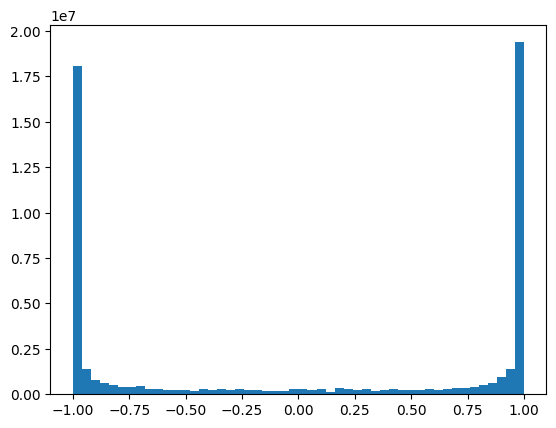

In [26]:
print(h[20])
plt.hist(h.view(-1).tolist(),50)

Notice how a large number is either -1 or 1, suggested that we have a lot of saturated tanh. An issue we have to solve. This histogram however is a bit deceptive. Lets track back a bit to understand why, remember, to get 'h' in the first place we went through this process:

C=torch.randn((27,n_embedding) -> C = (27,10)

W1=torch.randn(n_embedding * block_size, n_hidden1, requires_grad=True) -> w1 = (30,300)

Xtr = (182625,3)

emb = C[Xtr] -> emb = (182625,3,10)

x = emb.view(-1,n_embedding * block_size) -> x = (182625, 30)

h=torch.tanh(x @ W1 + b1) -> h = (182625, 30) @ (30,300) = (182625,300)


Intuitively, this means that for every one of the 182625 examples 'h' produce an 'activation' for each of the 300 neurons.

The above histogram 'plt.hist(h.view(-1).tolist(),50)' essentially flattens this list by displaying all of the '182625 * 300 = 54,787,500' activations all at once. In order to understand why this is deceptive we need to differentiate between a 'saturated tanh' and a completely 'dead neuron'. As displayed above we have 300 neurons, lets say for one of those 182625 examples we discovered that the tanh is saturated. This doesn't necessarily mean that neuron is useless. A neuron is only really 'dead' if the tanh is saturated for all of the 182625 examples.

The next step is to visualize the tanh saturation for each neuron across the 182625 examples to see if any neurons are 'dead' or if any neurons have a large number of saturated tanh's. The more saturated tanhs in a neuron, the less it can train

For visualization purposes, we will look at the graph for 'h_b', which is 'h' for a mini-batch of 32, rather than for the whole dataset

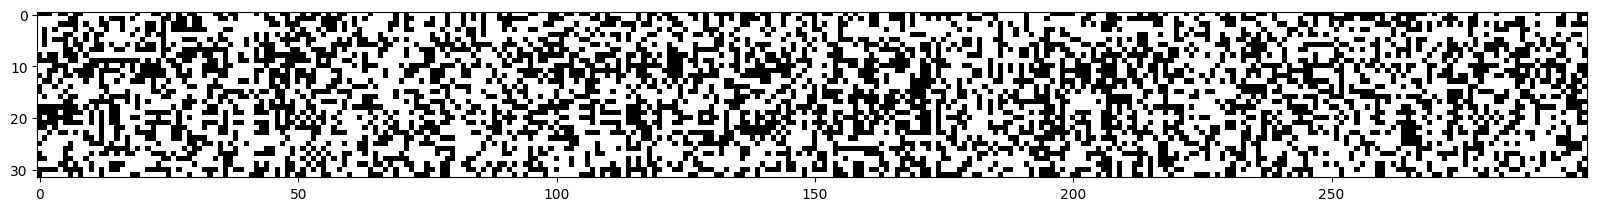

In [27]:
plt.figure(figsize=(20,10))
plt.imshow(h_b.abs() > 0.99, cmap='grey', interpolation='nearest')

If h_b.abs() > 0.99 is true the chart shows white. If its false it shows black. The large amount of white is consistent with the large number of saturated tanh which we previously determined. Although, visually, it doesn't seem like any neuron is fully dead. Regardless, we will still work on trying to improve this situation. Once again, lets take a step backwards. What results in 'h' = 1 ? Remember that h = tanh(z), where z = x @ W1 + b1. For h = +-1, z absolute value must be large (eg tanh(3)=0.995). Lets visualize the chart of z

(array([2.000000e+00, 4.140000e+02, 2.440000e+02, 6.270000e+02,
        1.042000e+03, 2.874000e+03, 4.802000e+03, 5.779000e+03,
        1.484500e+04, 2.428100e+04, 3.786400e+04, 6.089000e+04,
        1.091450e+05, 1.814370e+05, 3.274630e+05, 5.258370e+05,
        7.980150e+05, 1.231239e+06, 1.610871e+06, 2.021091e+06,
        2.725132e+06, 3.257382e+06, 3.698598e+06, 4.220669e+06,
        5.111459e+06, 5.571856e+06, 4.466417e+06, 3.854353e+06,
        3.487569e+06, 3.135354e+06, 2.491733e+06, 1.935087e+06,
        1.297812e+06, 9.013570e+05, 6.651160e+05, 4.140190e+05,
        2.708220e+05, 1.356500e+05, 8.510600e+04, 4.680800e+04,
        2.850800e+04, 1.480800e+04, 6.692000e+03, 3.046000e+03,
        1.693000e+03, 8.200000e+02, 6.880000e+02, 8.200000e+01,
        9.400000e+01, 8.000000e+00]),
 array([-27.82147026, -26.71324902, -25.60502777, -24.49680653,
        -23.38858528, -22.28036404, -21.17214279, -20.06392155,
        -18.9557003 , -17.84747906, -16.73925781, -15.63103657,
  

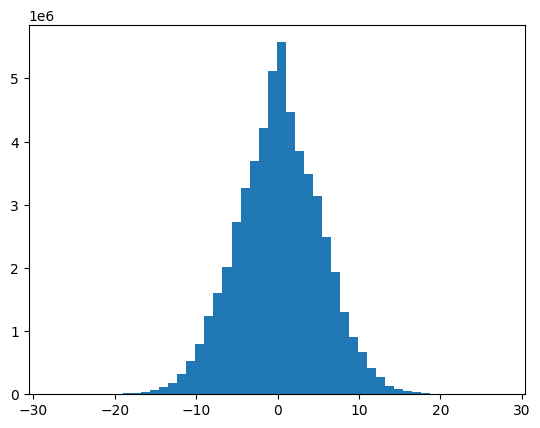

In [28]:
plt.hist(( x @ W1 + b1).view(-1).tolist(),50)

Notice how there are a lot of values which are big, this confirms our hypothesis. Hence, our next step is to reduce the size of the pre-activation (x @ W1 + b1), we can do this by scaling W1 and b1 down. Then, we will re-run the model and inspect the updated results

(0, 3.3064188957214355)
(1, 3.214510202407837)
(2, 3.215421438217163)
(3, 3.1527934074401855)
(4, 3.1450185775756836)
(5, 3.0853781700134277)
(6, 2.950294256210327)
(7, 3.1279280185699463)
(8, 2.9210567474365234)
(9, 2.9554696083068848)
(10, 2.8244388103485107)
(11, 2.7552220821380615)
(12, 2.625577926635742)
(13, 2.8571131229400635)
(14, 2.665849447250366)
(15, 2.9899494647979736)
(16, 2.793102502822876)
(17, 2.825167655944824)
(18, 2.6117196083068848)
(19, 2.751218795776367)
(20, 2.9538588523864746)
(21, 2.866077184677124)
(22, 2.693871021270752)
(23, 2.7121658325195312)
(24, 2.5765514373779297)
(25, 2.8279318809509277)
(26, 2.637995958328247)
(27, 2.703909397125244)
(28, 2.980820417404175)
(29, 3.058576822280884)
(30, 2.8273937702178955)
(31, 2.5645911693573)
(32, 2.9945571422576904)
(33, 2.61580491065979)
(34, 2.7367591857910156)
(35, 2.859257936477661)
(36, 2.852332830429077)
(37, 2.7072830200195312)
(38, 2.682400941848755)
(39, 2.7335681915283203)
(40, 2.7116549015045166)
(41, 2.

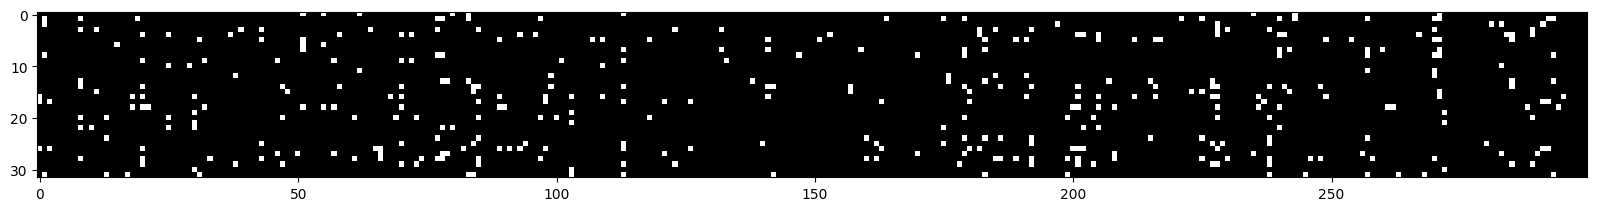

In [30]:
#Building MLP and setting up the training loop
torch.manual_seed(2147483647)

num_iterations = 15000
learning_rate = 0.01
n_hidden1 = 300
n_hidden2 = 27
n_embedding = 10
block_size = 3


C=torch.randn((27,n_embedding), requires_grad=True)
emb = C[Xtr]
x = emb.view(-1, n_embedding * block_size)


W1=torch.randn(n_embedding * block_size, n_hidden1) * 0.2
W1.requires_grad = True
b1=torch.randn(n_hidden1) * 0.02
b1.requires_grad = True


W2 = torch.randn(n_hidden1, n_hidden2) * 0.01
W2.requires_grad = True
b2 = torch.zeros(n_hidden2, requires_grad=True)

for k in range(num_iterations):
    #Mini-batch
    ix = torch.randint(0, Xtr.shape[0], (32,))
    #Forward Pass
    emb = C[Xtr[ix]]
    x = emb.view(-1, n_embedding * block_size)
    h_b = torch.tanh(x @ W1 + b1)
    logits = h_b @ W2 + b2

    #Loss
    mean_neg_log = F.cross_entropy(logits, Ytr[ix])

    #Backward Pass
    mean_neg_log.backward()

    #Update

    learning_rate = 0.1 if k < 0.75 * num_iterations else 0.01
    C.data += learning_rate * -C.grad
    W1.data += learning_rate * -W1.grad
    W2.data += learning_rate * -W2.grad
    b1.data += learning_rate * -b1.grad
    b2.data += learning_rate * -b2.grad
    C.grad.zero_()
    W1.grad.zero_()
    W2.grad.zero_()
    b1.grad.zero_()
    b2.grad.zero_()

    #Logging
    print((k, mean_neg_log.item()))

#Evaluating trained model on validation data - compare with final training loss

#Forward Pass on validation data
emb = C[Xval]
x = emb.view(-1,n_embedding * block_size)
h=torch.tanh(x @ W1 + b1)
logits = h @ W2 + b2


#Loss
mean_neg_log = F.cross_entropy(logits, Yval)

print(f"\nValidation Loss:",mean_neg_log.item())


#Forward Pass on training data - final training loss
emb = C[Xtr]
x = emb.view(-1,n_embedding * block_size)
h=torch.tanh(x @ W1 + b1)
logits = h @ W2 + b2


#Loss
mean_neg_log = F.cross_entropy(logits, Ytr)

print(f"\nFinal Training Loss:",mean_neg_log.item())

plt.figure(figsize=(20,10))
plt.imshow(h_b.abs() > 0.99, cmap='grey', interpolation='nearest')

